# Analyse et Optimisation de Portefeuille par Secteur avec yfinance

## I - Collecte et préparation des données

### A) Import des packages et des bibliothèques.
Dans ce code nous allons dans un premier temps installer tous les packages dont nous aurons besoin pour ce projet. Puis importer les bibliothèques, où nous changeons les noms pour simplifier le code par la suite. On créé une liste "secteurs" qui contient tous les secteurs pour permettre d'avoir deux boucles et de simplifier le code.

In [5]:
#Installation des packages
#!pip install yfinance==0.2.54
#!pip install --upgrade pip
#!pip install seaborn

In [6]:
import yfinance as yf
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from scipy.optimize import minimize
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### B) Téléchager les données dans un dictionnaire

La seconde étape est de télécharger pour chaque secteur les tops ETF, companies et fonds mutuels. On créé dans un premier temps un dictionnaire qui va récupérer toutes les noms de ces instruments top etf, entreprises et mutual funds. Pour ne pas avoir un code trop chargé, nous faisons une boucle qui va pourcourir tous les secteurs de notre liste (qui contient tous les secteurs de yfinance), cette boucle réucpère les tickers des entreprises et implémente toutes les données dans le dictionnaire "instruments_secteurs".
Pour chaque secteurs je collecte les  top mutuals funds, ETF et entreprises. Des temps d'attente sont mis dans la boucle pour empêcher yahoo de blocker l'accès aux données. On récupère top_companies.index des entreprises car sinon yf.download ne fonctionne pas bien et je n'obtiens pas les tops entreprises.

### B) Téléchager les données dans un dictionnaire

La seconde étape est de télécharger pour chaque secteur les tops ETF, companies et fonds mutuels. On créé dans un premier temps un dictionnaire qui va récupérer toutes les noms de ces instruments top etf, entreprises et mutual funds. Pour ne pas avoir un code trop chargé, nous faisons une boucle qui va pourcourir tous les secteurs de notre liste (qui contient tous les secteurs de yfinance), cette boucle réucpère les tickers des entreprises et implémente toutes les données dans le dictionnaire **instruments_secteurs**.

Des temps d'attente sont mis dans la boucle pour empêcher yahoo de blocker l'accès aux données. On récupère top_companies.index des entreprises car sinon yf.download ne fonctionne pas correctement et nous n'obtenons pas les tops entreprises.

### C) Téléchargement des données de cours

Ici le dictionnaire qui contiendra les données est créé, il s'appelle **donnees_historiques**. On fait une boucle qui va permettre de collecter les données des cours de tous les actifs sélectionnés dans **instruments_secteur**  sur les 15 dernières années.

On vérifie que les tickers n'apparaissent pas deux fois, puis on passe au téléchargement. Un message d'erreur est affiché si yfinance n'arrive pas à télécharger les données.

In [7]:
secteurs = [
    "basic-materials",
    "communication-services",
    "consumer-cyclical",
    "consumer-defensive",
    "energy",
    "financial-services",
    "healthcare",
    "industrials",
    "real-estate",
    "technology",
    "utilities"
]

#On créé un dictionnaire pour récupérer les données de la première boucle, et qui servira dans la deuxième boucle
instruments_secteur = {}

#Boucle pour récupérer les tickers des instruments, elle récupère pour chaque secteur les tickers des ETF, fonds mutuels et top entreprises
for secteur in secteurs:
#les deux print de la partie try et except servent à rendre compte du bon téléchargement ou non des données
    try:
        print(f"\n Collecte des instruments pour le secteur : {secteur}...")

        etfs = list(yf.Sector(secteur).top_etfs)
        fonds_mutuels = list(yf.Sector(secteur).top_mutual_funds)
        entreprises = list(yf.Sector(secteur).top_companies.index)

        #
        instruments_secteur[secteur] = {
            'ETFs': etfs,
            'Fonds Mutuels': fonds_mutuels,
            'Entreprises': entreprises
        }

        # Pause pour éviter d'être bloqué par yahoo, ce qui est arrivé dans la précédente version de ce code
        time.sleep(2)

    except Exception as erreur:
        print(f"Erreur pour le secteur {secteur} : {erreur}")
        continue

# On vérifie qu'on a bien récupéré tous les noms des instruments et que le dictionnaire est bien ordonné
print("\n Données récupérées par secteur :")
print(instruments_secteur)

#Deuxième dictionnaire qui contiendra les données de cette deuxième boucle, celle ci contient les données extraites grâce à yfinance
donnees_historique = {}

for secteur, instruments in instruments_secteur.items():
    print(f"\n Téléchargement des données pour le secteur : {secteur}")

    #pour chaque secteur, on donne les tickers qu'on veut extraire: entreprise, ETF, fonds mutuels, vérification que les tickers n'apparaissent pas plusieurs fois
    tickers = instruments['ETFs'] + instruments['Fonds Mutuels'] + instruments['Entreprises']
    tickers = list(set(tickers))

    try:
        #on télécharge les données sur de début janvier 2010 à  fin décembre 2024, pour chaque ticker
        donnees_historique[secteur] = yf.download(tickers, start="2010-01-01", end="2024-12-31")
        time.sleep(1)

    except Exception as e:
        print(f"Erreur lors du téléchargement pour {secteur} : {e}")



 Collecte des instruments pour le secteur : basic-materials...

 Collecte des instruments pour le secteur : communication-services...

 Collecte des instruments pour le secteur : consumer-cyclical...

 Collecte des instruments pour le secteur : consumer-defensive...

 Collecte des instruments pour le secteur : energy...

 Collecte des instruments pour le secteur : financial-services...

 Collecte des instruments pour le secteur : healthcare...

 Collecte des instruments pour le secteur : industrials...

 Collecte des instruments pour le secteur : real-estate...

 Collecte des instruments pour le secteur : technology...

 Collecte des instruments pour le secteur : utilities...

 Données récupérées par secteur :
{'basic-materials': {'ETFs': ['XLB', 'VAW', 'XME', 'IYM', 'FMAT', 'FXZ', 'RSPM', 'SLX', 'PYZ', 'UYM'], 'Fonds Mutuels': ['VMIAX', 'FMFCX', 'FMFEX', 'FMFTX', 'FMFAX', 'FSDPX', 'FIJFX', 'FSCHX', '0P0001AMJA', 'BMPIX'], 'Entreprises': ['LIN', 'SCCO', 'NEM', 'CRH', 'SHW', 'FCX', 'EC

/tmp/ipython-input-1612999970.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  donnees_historique[secteur] = yf.download(tickers, start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  70 of 70 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SOLS', 'AUGO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262322000, endDate = 1735621200")')



 Téléchargement des données pour le secteur : communication-services


/tmp/ipython-input-1612999970.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  donnees_historique[secteur] = yf.download(tickers, start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  70 of 70 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['GXPC', 'STUB']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262322000, endDate = 1735621200")')



 Téléchargement des données pour le secteur : consumer-cyclical


...

/tmp/ipython-input-1612999970.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  donnees_historique[secteur] = yf.download(tickers, start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  70 of 70 completed



 Téléchargement des données pour le secteur : technology


/tmp/ipython-input-1612999970.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  donnees_historique[secteur] = yf.download(tickers, start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  70 of 70 completed



 Téléchargement des données pour le secteur : utilities


/tmp/ipython-input-1612999970.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  donnees_historique[secteur] = yf.download(tickers, start="2010-01-01", end="2024-12-31")
[*********************100%***********************]  70 of 70 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FFUZX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn\'t exist for startDate = 1262322000, endDate = 1735621200")')


## II - Analyse des performances par secteur

### A) Boucle de récupération des rendements

Création du dictionnaire **rendements_historiques** des actifs et données téléchargées dans **donnees_historiques**.

La boucle parcourt tous actifs, et on vérifie si les colonnes sont en multindex: par exemple avec les cours d'ouverture et de fermeture. Dans ce cas on extrait uniquement les cours de cloture ("Close" ou "Adj Close" en cas de dividendes), à partir desquels nous calculons les rendements.  

A hybrid price series was constructed by using adjusted (especially in dividend case) prices whenever available and falling back to unadjusted prices otherwise. Without this hybrid series, using only adjusted prices, too much NaN will appear to plot it in II-D.

Le calcul des rendements est fait grâce à la fonction pct_change() qui observe la variation en pourcentage entre deux jours consécutifs.
On supprime :
- les dates de début (qui n'ont pas de valeur de variation --> NA) avec dropna().
- les lignes où moins de 5 données sont présentes.

On garde uniquement les colonnes avec plus de 60% de valeurs non nulles sur l'ensemble des données de rendement, puis on les stocke dans **rendements_historiques**.

In [32]:
rendements_historiques = {}

for secteur, donnees_secteur in donnees_historique.items():

    # --- 1. Sélection du prix (Adj Close prioritaire, sinon Close) ---
    if isinstance(donnees_secteur.columns, pd.MultiIndex):

        level0 = donnees_secteur.columns.get_level_values(0)

        if "Adj Close" in level0 and "Close" in level0:
            adj_close = donnees_secteur.xs("Adj Close", level=0, axis=1)
            close = donnees_secteur.xs("Close", level=0, axis=1)
            prix = adj_close.combine_first(close)  # série hybride

        elif "Adj Close" in level0:
            prix = donnees_secteur.xs("Adj Close", level=0, axis=1)

        else:
            prix = donnees_secteur.xs("Close", level=0, axis=1)

    else:
        # Cas sans MultiIndex (sécurité)
        prix = donnees_secteur.copy()

    # --- 2. Calcul des rendements ---
    rendements = prix.pct_change(fill_method=None)

    # --- 3. Filtrage des colonnes (suffisamment d'observations) ---
    min_obs = int(0.6 * len(rendements))  # seuil relatif
    rendements = rendements.loc[:, rendements.count() > min_obs]

    # --- 4. Filtrage des lignes (au moins 5 instruments disponibles) ---
    rendements = rendements.dropna(thresh=5, axis=0)

    # --- 5. Stockage ---
    rendements_historiques[secteur] = rendements


### B) Fonction pour calculer le rendements moyen journaliers des type d'instruments par secteur

La fonction parcours les rendements moyens journalier d'un instrument d'un secteur (even if **rendements_secteurs** doesn't exist we'll associate the key, value of **rendements_historiques** dictionary).

1 - Récupération des tickers des actifs (haut de colonne) et transforme en liste.

2 - On trie les actifs selon leur catégorie basé sur les datas générales.

3 - On calcule la moyenne des rendements journaliers pour les 3 séries.

In [33]:
def calculer_rendements_moyens_par_type(secteur, rendements_secteur):
    tickers_disponibles = rendements_secteur.columns.tolist()

    etfs = [t for t in instruments_secteur[secteur]['ETFs'] if t in tickers_disponibles]
    # All ETFs of the sector reselected in the list that we kept.
    entreprises = [t for t in instruments_secteur[secteur]['Entreprises'] if t in tickers_disponibles]
    fonds_mutuels = [t for t in instruments_secteur[secteur]['Fonds Mutuels'] if t in tickers_disponibles]

    rendement_moyen_etfs = rendements_secteur[etfs].mean(axis=1) if etfs else None
    # If etfs else none = if no mean due to no information = no error
    rendement_moyen_entreprises = rendements_secteur[entreprises].mean(axis=1) if entreprises else None
    # Here axis = 1 allow to do the mean for each date, else it would have given the whole mean of the period.
    rendement_moyen_fonds = rendements_secteur[fonds_mutuels].mean(axis=1) if fonds_mutuels else None

    return rendement_moyen_etfs, rendement_moyen_entreprises, rendement_moyen_fonds


### C) Boucle de calcul de la moyenne des moyenne de rendements journaliser par instrument par secteur

La boucle parcourt chaque secteur du dictionnaire **rendements_historiques**, calcule la moyenne journalière de chaque classe d'actifs via **calculer_rendement_moyens_par_type** et récupère les données dans r_etf, r_entr, r_fonds.

Ensuite, on calcule la moyenne globale de ces rendements journaliers sur 15 ans qu'on stocke dans **performance_secteurs**.

In [34]:
performances_secteurs = {}

#Ici on sélectionne la clé, valeur du dictionnaire en changeant le nom pour retrouver celui de la fonction.
for secteur, rendements_secteur in rendements_historiques.items():
    r_etf, r_entr, r_fonds = calculer_rendements_moyens_par_type(secteur, rendements_secteur)

    performances_secteurs[secteur] = {
        "Rendement Moyen ETF": r_etf.mean() if r_etf is not None else None,
        "Rendement Moyen Fonds": r_fonds.mean() if r_fonds is not None else None,
        "Rendement Moyen Entreprises": r_entr.mean() if r_entr is not None else None
    }


### D) Graphique de rendements cumulés par type d’actif pour chaque secteur


#### D-1) Code

Ici on visualiser l’évolution des rendements cumulés moyens des ETF, entreprises et fonds mutuels pour chaque secteur.
Le code commence par une boucle sur tous les secteurs dans rendements_historiques. Pour chaque secteur, on utilise la fonction calculer_rendements_moyens_par_type pour récupérer : r_etf, r_entr, r_fonds, de la manière que dans le code précédent
Ensuite on vérifie que au moins un des trois instruments a des données disponibles.
Si oui : On crée un graphique (plt.figure). On trace la somme cumulée des rendements journaliers (via .cumsum()), ce qui donne la croissance cumulée des investissements sur la période

Chaque type d’actif est tracé dans une couleur différente, bleu,rouge, vert.
Le graphique contient :
- Titre adopte le nom de chaque secteur
- En abscisse on retrouve le temps
- En ordonnée le rendement cumulé
- On a une légende pour distinguer les intruments
- On fait une mise en page propre

Si aucun rendement n’est disponible pour un secteur, on affiche un message pour indiquer qu’il n’est pas exploitable.


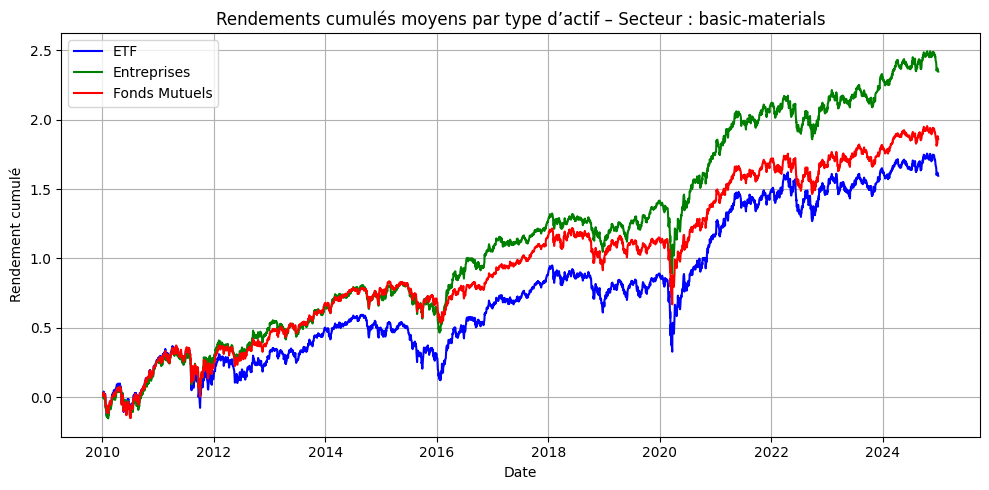

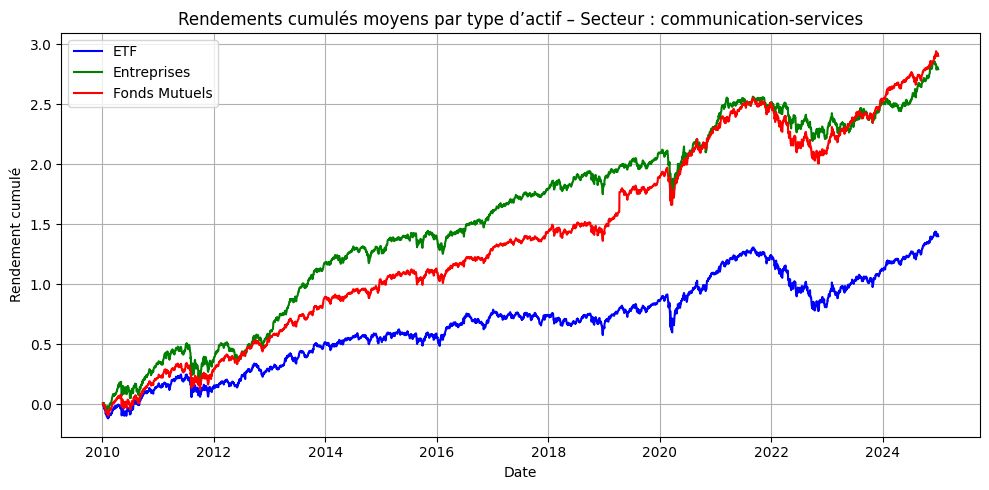

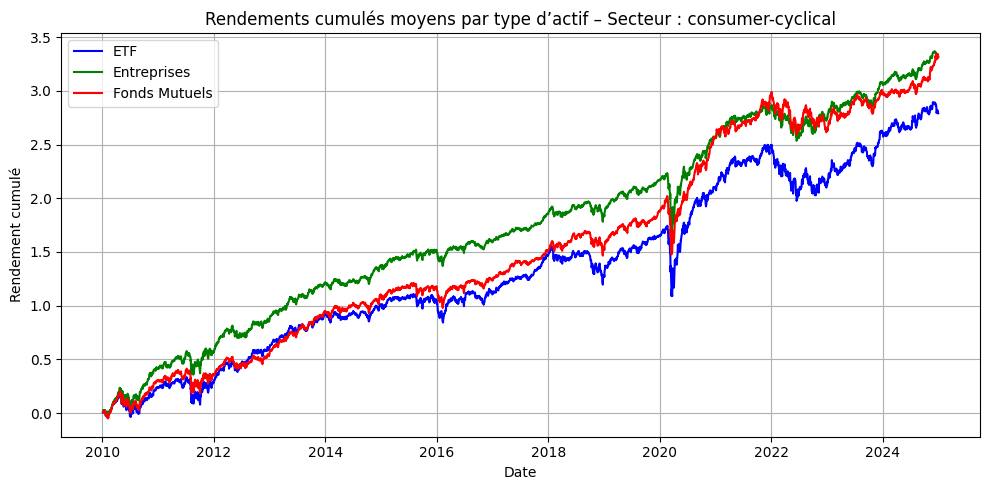

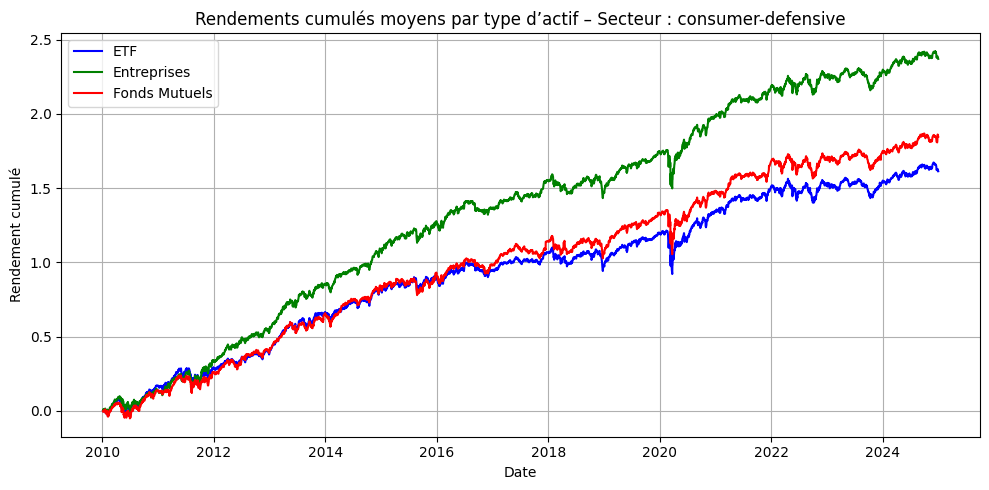

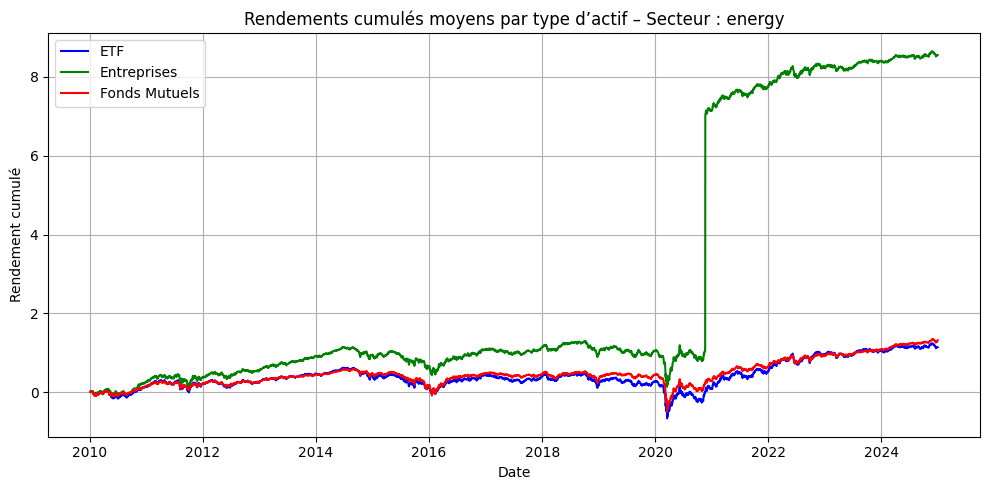

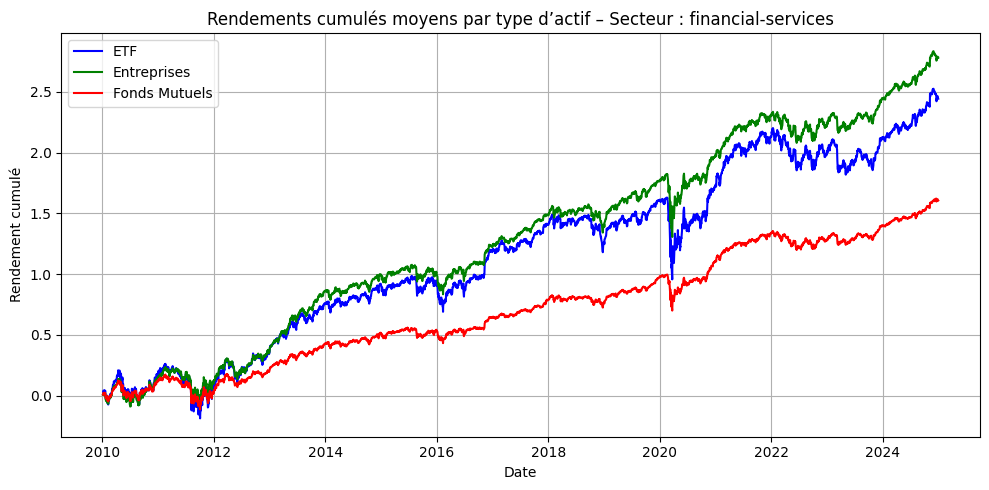

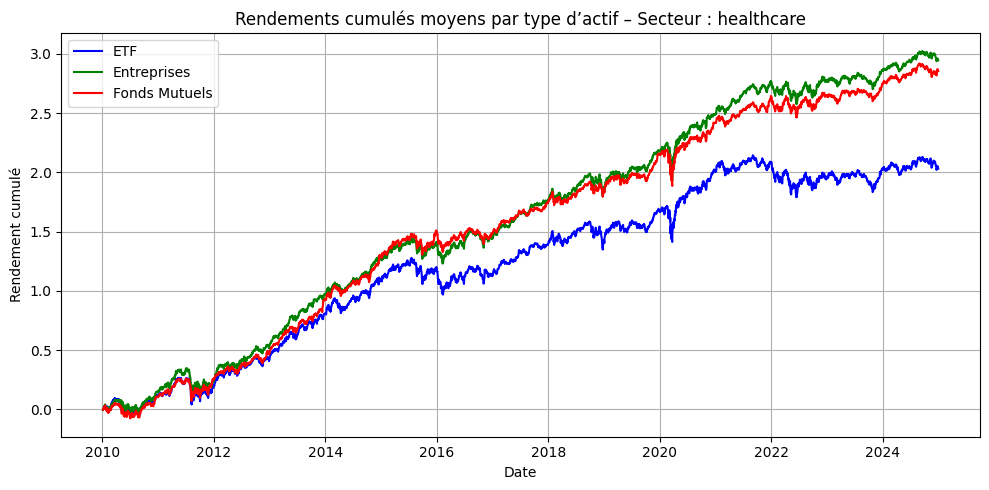

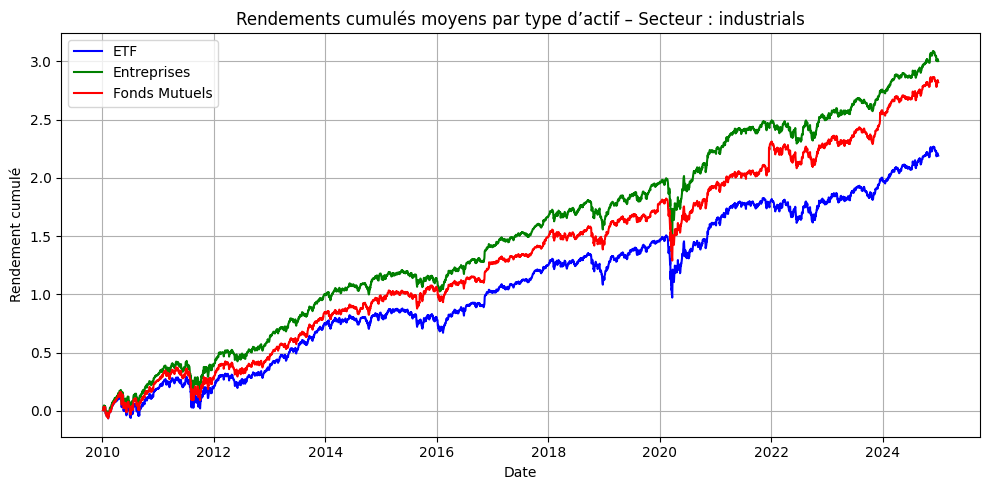

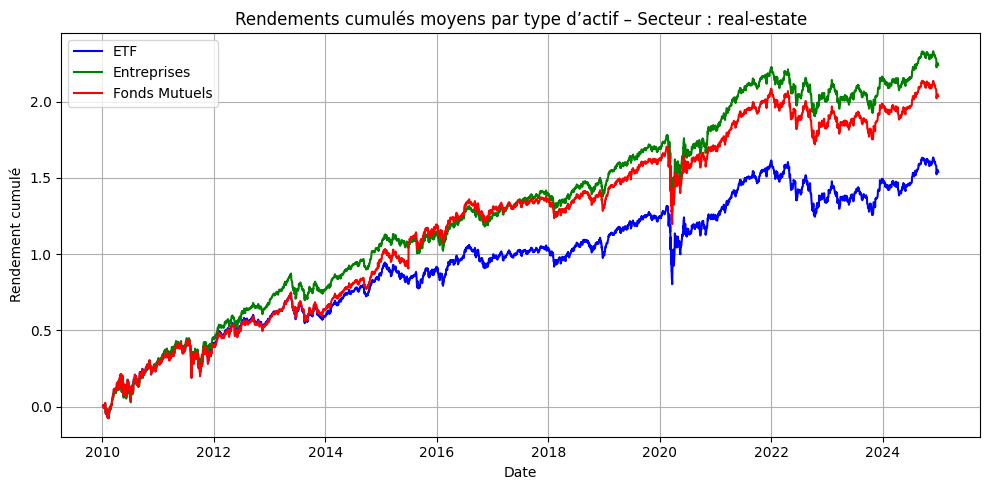

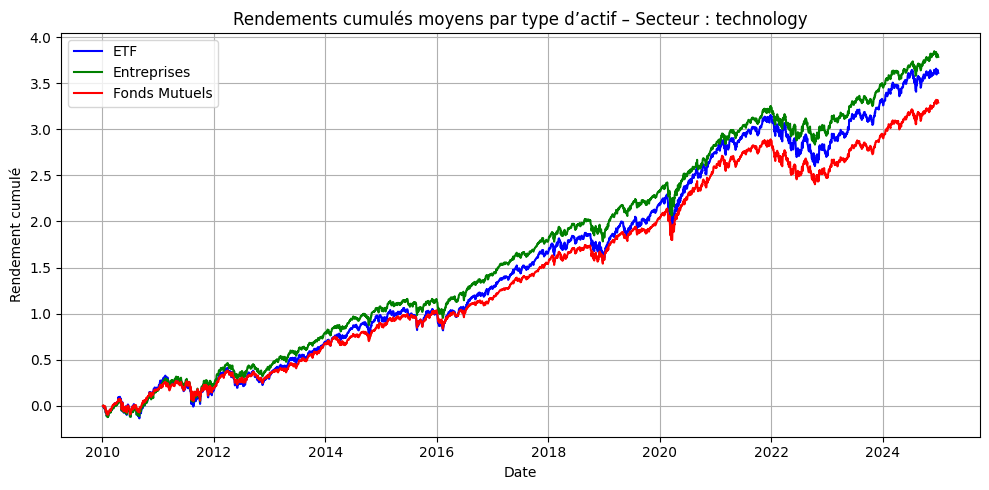

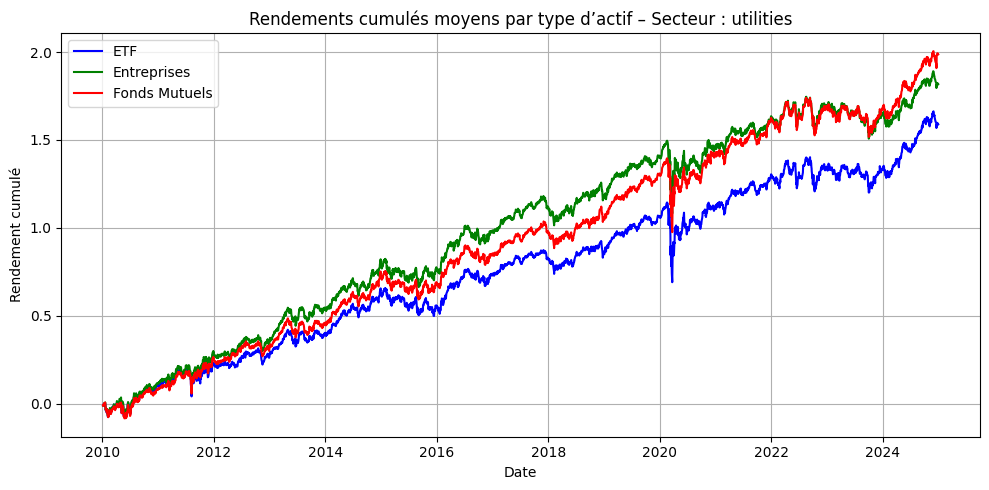

In [35]:
for secteur, rendements_secteur in rendements_historiques.items():
    r_etf, r_entr, r_fonds = calculer_rendements_moyens_par_type(secteur, rendements_secteur)

    if any(r is not None for r in [r_etf, r_entr, r_fonds]):
        plt.figure(figsize=(10, 5))

        if r_etf is not None:
            plt.plot(r_etf.cumsum(), label='ETF', color='blue')
        if r_entr is not None:
            plt.plot(r_entr.cumsum(), label='Entreprises', color='green')
        if r_fonds is not None:
            plt.plot(r_fonds.cumsum(), label='Fonds Mutuels', color='red')

        plt.title(f"Rendements cumulés moyens par type d’actif – Secteur : {secteur}")
        plt.xlabel("Date")
        plt.ylabel("Rendement cumulé")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Aucune donnée exploitable pour le secteur : {secteur}")


Aucune donnée exploitable pour le secteur : basic-materials
Aucune donnée exploitable pour le secteur : communication-services


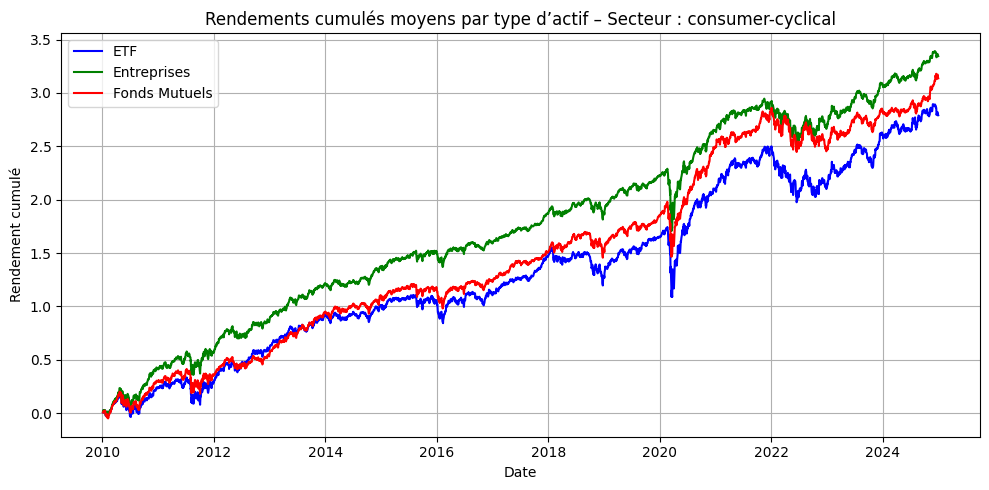

Aucune donnée exploitable pour le secteur : consumer-defensive
Aucune donnée exploitable pour le secteur : energy


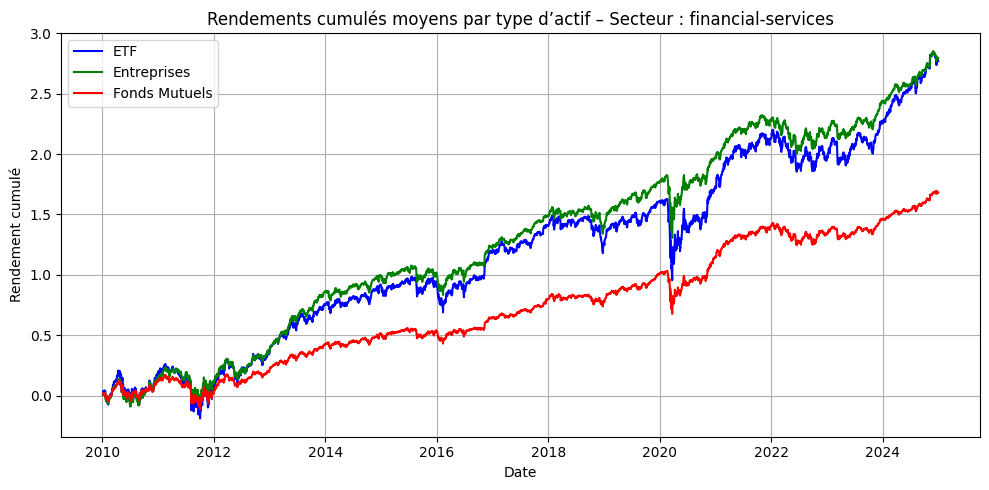

Aucune donnée exploitable pour le secteur : healthcare
Aucune donnée exploitable pour le secteur : industrials


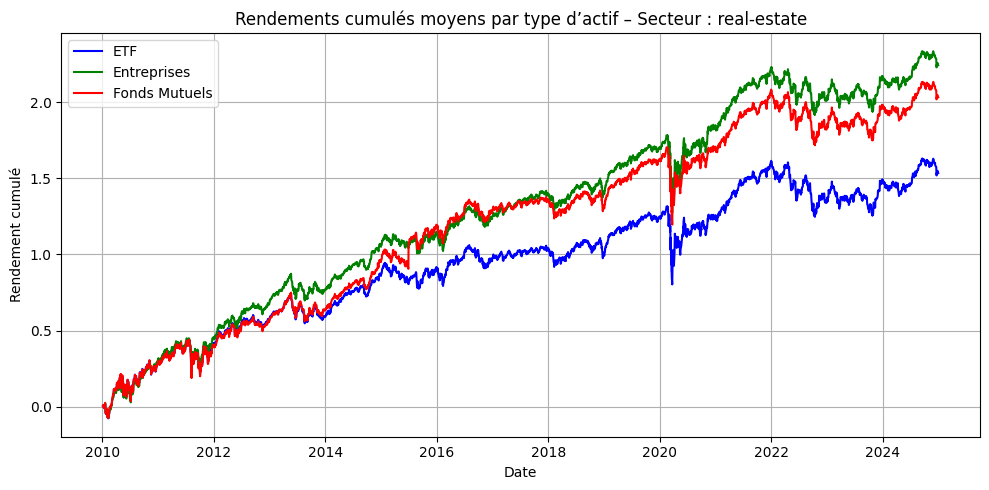

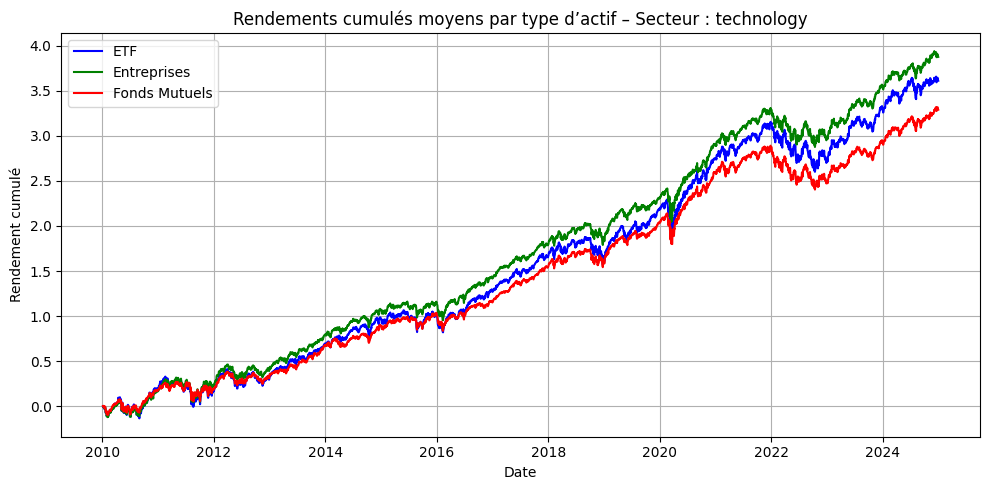

Aucune donnée exploitable pour le secteur : utilities


In [27]:
for secteur, rendements_secteur in rendements_historiques.items():
    r_etf, r_entr, r_fonds = calculer_rendements_moyens_par_type(secteur, rendements_secteur)

    if any(r is not None for r in [r_etf, r_entr, r_fonds]):
        plt.figure(figsize=(10, 5))

        if r_etf is not None:
            plt.plot(r_etf.cumsum(), label='ETF', color='blue')
        if r_entr is not None:
            plt.plot(r_entr.cumsum(), label='Entreprises', color='green')
        if r_fonds is not None:
            plt.plot(r_fonds.cumsum(), label='Fonds Mutuels', color='red')

        plt.title(f"Rendements cumulés moyens par type d’actif – Secteur : {secteur}")
        plt.xlabel("Date")
        plt.ylabel("Rendement cumulé")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Aucune donnée exploitable pour le secteur : {secteur}")

#### D-2) Interprétation des résultats

Ici on abserve avec la visualisation des données que les entreprises surperforment dans tous les cas les ETF et fonds mutuels. Cependant on observe deux graphiques totalement anormaux, notamment celui du secteur real estate et celui du secteur energy. En effet, ils ont des importantes croissances à un moment donné, pour real estate à un point tel que cela écrase totalement les autres courbes des ETF et fonds mutuels. On cherche dans un premier temps à comprendre cela, pour ensuite le corriger. Nous commençons par essayer de comprendre pour real estate.

Il ne faut pas oublier que nous importons nos données de yfinance, ce qui implique que les top etfs etc... d'aujourd'hui sont considérés comme top pour l'ensemble de la période ce qui n'est pas forcément le cas. Pour avoir une comparaison plus fine et correcte, il aurait fallu télécharger les top actifs par quarter par exemple et calculer les rendements sur cette période, et actualiser les top chaque quarter afin d'améliorer la précision des rendements cumulés de ces tops actifs. Pour faire cela, nous devons accéder à une base payante de données (style Bloomberg, ou Morningstar) ce que nous n'avons pas ici.

### E) Analyse des données

In [ ]:
# Boucle pour récupérer les rendements journaliers moyens de chaque top entreprise de real estate
secteur = 'real-estate'
rendements_re = rendements_historiques.get(secteur)

if rendements_re is not None:
    # On récupère les entreprises de real estate
    entreprises_re = [t for t in instruments_secteur[secteur]['Entreprises'] if t in rendements_re.columns]
    # on récupére les colonne des entreprises
    rendements_entreprises_re = rendements_re[entreprises_re]
    # calcule du rendement moyen journalier sur la période de 15 ans
    rendement_moyen_par_entreprise = rendements_entreprises_re.mean()
    # On sort les entreprises avec les rendements moyens triés du plus élevé au moins élevé
    rendement_moyen_par_entreprise = rendement_moyen_par_entreprise.sort_values(ascending=False)
    print(rendement_moyen_par_entreprise)
else:
    print("Le secteur 'real-estate' n'existe pas dans les données.")
rendements_entreprises_re.describe()

Comme montré ci dessus, nous obsevrons que l'entrerpise SZRRF a un rendement moyen quotidien de 41%, très anormalement élevé, ce qui est impossible. Cette donnée écrase donc toutes les autres entreprises du secteur, ce qui biaise complètement notre analyse future. Nous avons vérifié le cours de cet actif sur yahoo finance, et en effet il y a un problème le concernant, il passe d'une valorisation presque nulle à 40$ d'un seul coup, sans variation du prix. On en déduit que cette entreprise fausse nos résultats. Ainsi, à partir de maintenant, nous allons enlever cette entreprise du secteur real estate.

Après recherche le ticker SZRRF = Saizen Real Estate Investment Trust, est une compagnie d'investissement singapourienne qui a liquidé ses positions (notamment dans l'immobilier japonais) lors de son rachat et son delisting. Ce qui a engendré une hausse spectaculaire des dividedes, et a modifié drastiquement le graphique. En Décembre 2025 en relançant le script, l'erreur a disparu car son delisting ne la fait plus rentrer dans les rendements étudiés.

#### E-2) Analyse energy

In [ ]:
# Boucle pour récupérer les rendements journaliers moyens de chaque top entreprise de real estate
secteur = 'energy'
rendements_re = rendements_historiques.get(secteur)

if rendements_re is not None:
    # On récupère les entreprises d'energy
    entreprises_re = [t for t in instruments_secteur[secteur]['Entreprises'] if t in rendements_re.columns]
    # on récupére les colonne des entreprises
    rendements_entreprises_re = rendements_re[entreprises_re]
    #calcule du rendement moyen journalier sur la période de 15 ans
    rendement_moyen_par_entreprise = rendements_entreprises_re.mean()
    # On sort les entreprises avec les rendements moyens triés du plus élevé au moins élevé
    rendement_moyen_par_entreprise = rendement_moyen_par_entreprise.sort_values(ascending=False)
    print(rendement_moyen_par_entreprise)
else:
    print("Le secteur 'energy' n'existe pas dans les données.")
#rendements_entreprises_re.describe()

On peut observer la croissance cumulée de CHRD qui est très élevées à plus de 7% par jour en moyenne. Contrairement à Real Estate, après les avoir confrontées à d'autres sources, et observé les graphiques de cette entreprise sur yahoo fiannce, on observe que les données sont justes, il est alors plus compliqué de la supprimer. On va alors la conserver mais en plafonnant sa croissance journalière maximum à 5% pour quand même voir sa hausse mais sans applatir nos données. C'était le problème que nous avions avant d'essayer de traiter cette donnée. Cela est fait pour plus de clarté dans les résultats obteus plus tard, tout en la conservant, et en la laissant contribuer à la croissance du secteur.  

## 6) Reexécution du code après correction

On créé la fonction calculer_rendements_moyens_par_type qui supprime ces données dans cette fonction dans un premier temps pour analyser nos résultats après correction.

In [19]:
def calculer_rendements_moyens_par_type(secteur, rendements_secteur):
    tickers_disponibles = rendements_secteur.columns.tolist()

    if secteur == "real-estate" and "SZRRF" in tickers_disponibles:
        rendements_secteur = rendements_secteur.drop(columns="SZRRF")

    if secteur == "energy" and "CHRD" in tickers_disponibles:
        rendements_secteur = rendements_secteur.copy()
        rendements_secteur["CHRD"] = rendements_secteur["CHRD"].clip(upper=0.05)

    etfs = [t for t in instruments_secteur[secteur]['ETFs'] if t in rendements_secteur.columns]
    entreprises = [t for t in instruments_secteur[secteur]['Entreprises'] if t in rendements_secteur.columns]
    fonds_mutuels = [t for t in instruments_secteur[secteur]['Fonds Mutuels'] if t in rendements_secteur.columns]

    rendement_moyen_etfs = rendements_secteur[etfs].mean(axis=1) if etfs else None
    rendement_moyen_entreprises = rendements_secteur[entreprises].mean(axis=1) if entreprises else None
    rendement_moyen_fonds = rendements_secteur[fonds_mutuels].mean(axis=1) if fonds_mutuels else None

    return rendement_moyen_etfs, rendement_moyen_entreprises, rendement_moyen_fonds

Aucune donnée exploitable pour le secteur : basic-materials
Aucune donnée exploitable pour le secteur : communication-services


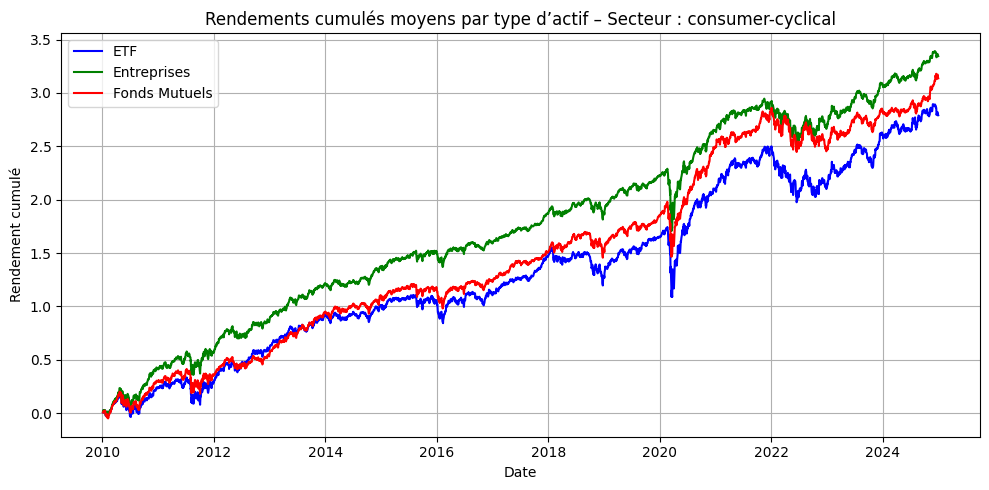

Aucune donnée exploitable pour le secteur : consumer-defensive
Aucune donnée exploitable pour le secteur : energy


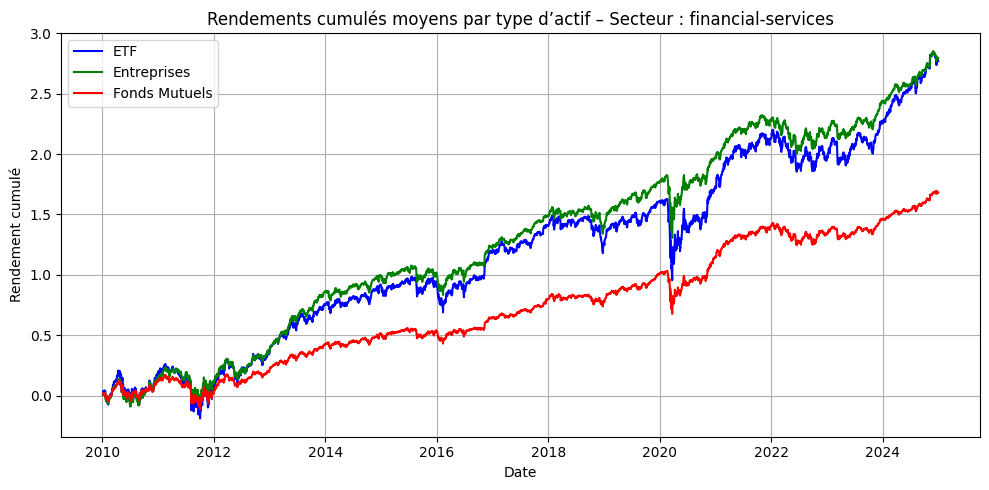

Aucune donnée exploitable pour le secteur : healthcare
Aucune donnée exploitable pour le secteur : industrials


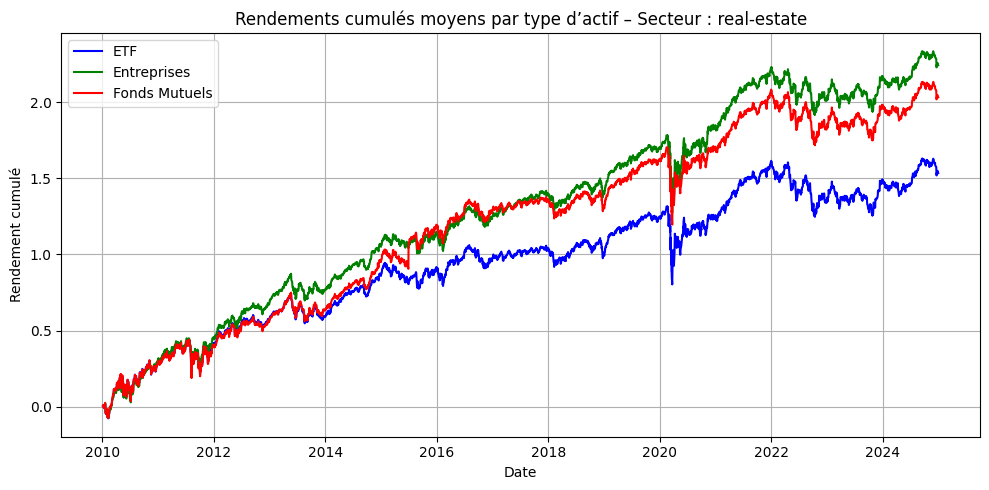

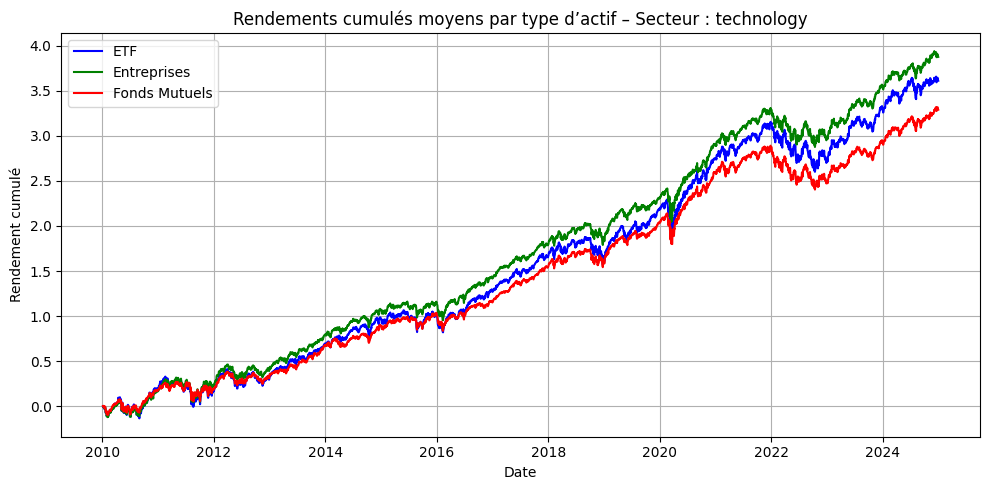

Aucune donnée exploitable pour le secteur : utilities


In [21]:
performances_secteurs = {}

for secteur, rendements_secteur in rendements_historiques.items():
    r_etf, r_entr, r_fonds = calculer_rendements_moyens_par_type(secteur, rendements_secteur)

    performances_secteurs[secteur] = {
        "Rendement Moyen ETF": r_etf.mean() if r_etf is not None else None,
        "Rendement Moyen Fonds": r_fonds.mean() if r_fonds is not None else None,
        "Rendement Moyen Entreprises": r_entr.mean() if r_entr is not None else None
    }
for secteur, rendements_secteur in rendements_historiques.items():
    r_etf, r_entr, r_fonds = calculer_rendements_moyens_par_type(secteur, rendements_secteur)

    if any(r is not None for r in [r_etf, r_entr, r_fonds]):
        plt.figure(figsize=(10, 5))

        if r_etf is not None:
            plt.plot(r_etf.cumsum(), label='ETF', color='blue')
        if r_entr is not None:
            plt.plot(r_entr.cumsum(), label='Entreprises', color='green')
        if r_fonds is not None:
            plt.plot(r_fonds.cumsum(), label='Fonds Mutuels', color='red')

        plt.title(f"Rendements cumulés moyens par type d’actif – Secteur : {secteur}")
        plt.xlabel("Date")
        plt.ylabel("Rendement cumulé")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Aucune donnée exploitable pour le secteur : {secteur}")

### Interprétation des résultats
Maintenant les graphiques paraissent normaux après correction, on a réglé notre problème. Les entreprises semblent toujours surperformer les ETF et mutual funds.

# Graphiques par secteur

Ensuite, pour chaque secteur, on trace un graphique unique avec les courbes des trois stratégies illustrées dessus. Cela permet de voir quelle stratégie fonctionne le mieux dans un secteur donné, et comment leur performance évolue dans le temps.
Cette section permet de tester l’efficacité de différentes approches d’optimisation à l’intérieur de chaque secteur, et de les comparer sur la période 2010–2024.

Donc la suppression et le plafonnage de croissance ont fonctionné, on en déduit qu'il va falloir appliquer ces modifications dans nos données.



## Suppression de SZRRF pour le secteur real estate et plafonnage de la croissance de CHRD

In [22]:
secteur_real_estate = "real-estate"
entreprise_a_supprimer = "SZRRF"

if secteur_real_estate in rendements_historiques:
    df_real_estate = rendements_historiques[secteur_real_estate]
    if entreprise_a_supprimer in df_real_estate.columns:
        df_real_estate = df_real_estate.drop(columns=[entreprise_a_supprimer])
        rendements_historiques[secteur_real_estate] = df_real_estate
        print(f"L'entreprise {entreprise_a_supprimer} a bien été supprimée du secteur {secteur_real_estate}.")
    else:
        print(f"{entreprise_a_supprimer} n'est pas présent dans les colonnes du secteur {secteur_real_estate}.")
else:
    print(f"{secteur_real_estate} n'existe pas dans le dictionnaire.")

secteur_energy = "energy"
entreprise_a_plafonner = "CHRD"

if secteur_energy in rendements_historiques:
    df_energy = rendements_historiques[secteur_energy]
    if entreprise_a_plafonner in df_energy.columns:
        df_energy[entreprise_a_plafonner] = df_energy[entreprise_a_plafonner].clip(upper=0.05)
        rendements_historiques[secteur_energy] = df_energy
        print(f"Les rendements de {entreprise_a_plafonner} ont été plafonnés à 5% par jour dans le secteur {secteur_energy}.")
    else:
        print(f"{entreprise_a_plafonner} n'est pas présent dans les colonnes du secteur {secteur_energy}.")
else:
    print(f"{secteur_energy} n'existe pas dans le dictionnaire.")


SZRRF n'est pas présent dans les colonnes du secteur real-estate.
CHRD n'est pas présent dans les colonnes du secteur energy.


## 1) Création des dates de rééquilibrage et du dictionnaire qui prendra les performance optimisées

On commence par créer une liste de dates espacées de 3 mois, entre janvier 2010 et décembre 2024. Ces dates vont servir de point de repère pour recalculer les pondérations du portefeuille sectoriel. On fait comme un investisseur qui ajuste son portefeuille à chaque trimestre.

On prépare un dictionnaire nommé performances_portefeuilles pour stocker les performances obtenues par secteur et par stratégie. Il y a trois stratégies d’optimisation : minimisation de la variance, maximisation du ratio de Sharpe, et maximisation de la diversification. Une clé dates est ajoutée pour garder la chronologie des performances.

In [23]:
#on fait une liste de dates espacées de 3 mois sur les 15ans de nos données
dates_reequilibrage = pd.date_range(start='2010-04-01', end='2024-12-31', freq='3MS')

# On fait un dictionnaire qui sotcke les performances pour chacune des 3 stratégies
performances_portefeuilles = {
    'variance': {secteur: [] for secteur in rendements_historiques},
    'sharpe': {secteur: [] for secteur in rendements_historiques},
    'diversification': {secteur: [] for secteur in rendements_historiques},
    'dates': []
}

## 2) Définition de la fonction d’optimisation

La fonction optimiser_portefeuille() permet de résoudre un problème d’optimisation sous contraintes à l’aide de la fonction minimize(). On établit arbitrairement que le taux sans risque(qui sera utilisé pour la ratio de Sharpe) est à 1%.Le poids des actifs est contraint entre 0 et 10%, et la seconde contrainte est que la somme des poids fasse 1.

- volatilite_portefeuille calcule la volatilité totale du portefeuille avec les poids proposés.
- negatif_sharpe caclule le ratio de Sharpe avec les poids proposés. On le calcule avec le rapport entre le rendement excédentaire et le risque. On rend ce ratio négatif car on va chercher à le maximiser, donc minimiser le ratio de Sharpe négatif permet de maximiser.
- negatif_diversification, on fait la moyenne pondérée des volatilités individuelles sur la volatilité globale. On le rend négatif pour la même raison que le ratio de Sharpe.

Puis la dernière partie sert à utiliser la fonction approprié en fonction de quelle stratégie on veut. Et c'est cette partie qui va optimiser avec la fonction minimise. SLSQP est la méthode qui permet de résoudre le problème sous contrainte.

In [24]:
def optimiser_portefeuille(rendements_moyens, matrice_cov, objectif, taux_sans_risque=0.01):
    nb_actifs = len(rendements_moyens)
    #on fait en sorte que tous les actifs aient la même pondération dans le portefeuille
    poids_initiaux = np.ones(nb_actifs) / nb_actifs
    # On a une quantité entre 0 et 10% d'un actif, pour ne pas avoir un actif trop prépondérant dans le portefeuille
    bornes = [(0, 0.1)] * nb_actifs
    #On établit la contrainte pour que la somme des poids des actifs soit égalle à 1
    contraintes = [{'type': 'eq', 'fun': lambda poids: np.sum(poids) - 1}]

    def volatilite_portefeuille(poids): return np.sqrt(poids.T @ matrice_cov @ poids)


    def negatif_sharpe(poids):
        rendement_portefeuille = poids @ rendements_moyens
        vol = volatilite_portefeuille(poids)
        return - (rendement_portefeuille - taux_sans_risque) / vol

    def negatif_diversification(poids):
        volatilites_indiv = np.sqrt(np.diag(matrice_cov))
        vol_total = volatilite_portefeuille(poids)
        return - (poids @ volatilites_indiv) / vol_total

    if objectif == 'variance':
        fonction_objectif = volatilite_portefeuille
    elif objectif == 'sharpe':
        fonction_objectif = negatif_sharpe#car on veut le maximiser, et la fonction va le minimiser
    elif objectif == 'diversification':
        fonction_objectif = negatif_diversification
    else:
        raise ValueError("Objectif inconnu.")

    resultat = minimize(fonction_objectif, poids_initiaux, method='SLSQP', bounds=bornes, constraints=contraintes)
    return resultat.x if resultat.success else poids_initiaux

## III - Boucle principale

La boucle principale itère sur toutes les dates de rééquilibrage. Pour chaque date, on regarde une fenêtre glissante allant de 2 ans à 3 mois avant cette date. Cette fenêtre sert de période d’apprentissage pour estimer les rendements moyens et la matrice de covariance.

On fait ensuite en sorte de filtrer les actifs pour ne garder que ceux ayant suffisamment de données (au moins 60 valeurs dans la fenêtre), afin d’éviter une erreur dans le code qui peut arriver si on a des données trop incomplètes.

Si au moins 3 actifs valides sont disponibles, les pondérations optimales sont calculées pour chaque stratégie. On obtient donc trois vecteurs de poids pour la stratégie variance, sharpe et diversification.

In [25]:
for date in dates_reequilibrage:
    performances_portefeuilles['dates'].append(date)

    for secteur, donnees_rendements in rendements_historiques.items():
        #on prend une plage de données de 2 ans à 3 mois avant notre date donnée
        debut_fenetre = date - pd.DateOffset(years=2)
        fin_fenetre = date - pd.DateOffset(months=3)
        fenetre = donnees_rendements.loc[debut_fenetre:fin_fenetre]

        seuil_validite = int(0.9 * len(fenetre))
        fenetre = fenetre.loc[:, fenetre.notna().sum() > seuil_validite]

        fenetre = fenetre.dropna()

        if fenetre.shape[1] < 3 or len(fenetre) < 60:
            continue

        rendements_moyens = fenetre.mean()
        matrice_cov = fenetre.cov()

        poids_variance = optimiser_portefeuille(rendements_moyens, matrice_cov, 'variance')
        poids_sharpe = optimiser_portefeuille(rendements_moyens, matrice_cov, 'sharpe')
        poids_div = optimiser_portefeuille(rendements_moyens, matrice_cov, 'diversification')

        actifs_valides = fenetre.columns
        trimestre_suivant = donnees_rendements.loc[date: date + pd.DateOffset(months=3), actifs_valides]

        if trimestre_suivant.empty:
            continue

        rendement_var = (trimestre_suivant @ poids_variance).mean()
        rendement_sharpe = (trimestre_suivant @ poids_sharpe).mean()
        rendement_div = (trimestre_suivant @ poids_div).mean()

        performances_portefeuilles['variance'][secteur].append(rendement_var)
        performances_portefeuilles['sharpe'][secteur].append(rendement_sharpe)
        performances_portefeuilles['diversification'][secteur].append(rendement_div)


KeyboardInterrupt: 

## 4)Graphiques par secteur

Ensuite, pour chaque secteur, on trace un graphique unique avec les courbes des trois stratégies illustrées dessus. Cela permet de voir quelle stratégie fonctionne le mieux dans un secteur donné, et comment leur performance évolue dans le temps.
Cette section permet de tester l’efficacité de différentes approches d’optimisation à l’intérieur de chaque secteur, et de les comparer sur la période 2010–2024.


In [ ]:
for secteur in rendements_historiques:
    plt.figure(figsize=(10, 5))

    for strategie, couleur in zip(['variance', 'sharpe', 'diversification'], ['blue', 'green', 'red']):
        perf = performances_portefeuilles[strategie][secteur]
        if len(perf) > 0:
            perf_cumulee = np.cumprod([1 + r for r in perf])
            dates = performances_portefeuilles['dates'][:len(perf_cumulee)]
            plt.plot(dates, perf_cumulee, label=strategie.capitalize(), color=couleur)

    plt.title(f"Performance cumulée des stratégies pour le secteur : {secteur}")
    plt.xlabel("Date")
    plt.ylabel("Croissance du portefeuille (échelle log)")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


# Interprétation des résultats
Les stratégies utilisant le ratio de Sharpe semblent être la plus efficace dans la majorité des cas la croissance des portefeuilles. A part real estate ou la stratégie de minimisation de la variance est ce qui permet d'avoir le meilleur rendement. On observe égallement que la stratégie basée sur Sharpe est ce qu'il y a de plus volatile en terme de rendement, donc la plus risquée, plus bas sur les périodes de baisse et plus haute sur les périodes de hausse. Il semble aussi que ces stratégie sous-performent le rendements des entreprises, ETF et fonds mutuels si on avait gardé notre argent placé sur les mêmes entreprises.

# IV/Comparaison intersectorielle
Dans cette section, les rendements journaliers de tous les instruments financiers sont agrégés par secteur afin de permettre une analyse globale et comparative.

## 1)Calcul des rendements jounaliers moyens par secteur


In [ ]:
## 1) Ici on va rassembler les données

### Concaténation des rendements journaliers de toutes les entreprises

Dans ce code on parcout tout rendement historiques et récupère les rendements de toutes les entreprises, il les concatène. On remplace les valeurs manquantes par des 0, ce n'est pas problématique car il s'agit de rendements. On calcule ensuite la moyenne des rendements, la matrice covariance gloable. Enfin il applique la fonction optimiser_portefeuille faite précédemment, ce qui permet d'obtenir les poids optimaux à attribuer à chaque entreprise.

In [ ]:
rendements_entreprises = []

for secteur, rendements in rendements_historiques.items():
    entreprises = instruments_secteur[secteur]['Entreprises']
    entreprises_valides = [e for e in entreprises if e in rendements.columns]
    if entreprises_valides:
        rendements_entreprises.append(rendements[entreprises_valides])

rendements_globaux = pd.concat(rendements_entreprises, axis=1).fillna(0)

rendements_moyens_globaux = rendements_globaux.mean()
covariance_globale = rendements_globaux.cov()

poids_opt_globaux = optimiser_portefeuille(rendements_moyens_globaux, covariance_globale, 'sharpe')


### Concaténation des rendements journaliers de toutes les entreprises

Ce code construit un tableau qui contient les rendements journaliers moyens des ETF pour chaque secteur.Il parcourt de la même manière les rendements historiques. Il récupère les ETF valides, il extrait leurs rendements journaliers, calcule leuurs moyennes. Puis il l’assigne à une colonne correspondant au secteur dans le DataFrame rendements_etf_par_secteur. Ce dataframe servira pour faire une optimisation par secteur.

In [ ]:
rendements_etf_par_secteur = pd.DataFrame()

for secteur, rendements in rendements_historiques.items():
    etfs = instruments_secteur[secteur]['ETFs']
    etfs_valides = [etf for etf in etfs if etf in rendements.columns]
    if etfs_valides:
        rendements_etfs = rendements[etfs_valides]
        rendement_moyen_etfs = rendements_etfs.mean(axis=1)
        rendements_etf_par_secteur[secteur] = rendement_moyen_etfs

rendements_etf_par_secteur.dropna(inplace=True)

rendements_moyens_secteurs = rendements_etf_par_secteur.mean()
covariance_secteurs = rendements_etf_par_secteur.cov()

poids_opt_secteurs = optimiser_portefeuille(rendements_moyens_secteurs, covariance_secteurs, 'sharpe')
perf_opt_secteurs = (rendements_etf_par_secteur @ poids_opt_secteurs).cumsum()
perf_opt_globaux = (rendements_globaux @ poids_opt_globaux).cumsum()




### Construction d'un portefeuille equipondéré par secteur

poids_egal_secteurs créé un vecteur de poid égal pour chaque secteur, donc chaque secteur à la même importance.
perf_egalitaire_secteurs va effectuer le produit matriciel entre les rendements journaliers moyens de chaque secteur et les poids equipondérés, cela donne les rendements journaliers du portefeuille équipondéré.

In [ ]:
poids_egal_secteurs = np.full(len(rendements_etf_par_secteur.columns), 1 / len(rendements_etf_par_secteur.columns))
perf_egalitaire_secteurs = (rendements_etf_par_secteur @ poids_egal_secteurs).cumsum()
perf_opt_secteurs = (rendements_etf_par_secteur @ poids_opt_secteurs).cumsum()
perf_opt_globaux = (rendements_globaux @ poids_opt_globaux).cumsum()

### Harmonisation des dates
Ici on s'assure que toutes les dates commencent et finissent en même temps.
La suite du code va utiliser ces dates pour filtrer chaque série de performances.

In [ ]:
sp500 = yf.download (tickers = "^GSPC", start="2010-01-01", end="2024-12-31")['Close']
rendements_sp500 = sp500.pct_change().dropna()
perf_sp500 = (1 + rendements_sp500).cumprod()

In [ ]:
dates_communes = perf_sp500.index.intersection(perf_egalitaire_secteurs.index).intersection(perf_opt_secteurs.index).intersection(perf_opt_globaux.index)

perf_sp500 = perf_sp500.loc[dates_communes]
perf_egalitaire_secteurs = perf_egalitaire_secteurs.loc[dates_communes]
perf_opt_secteurs = perf_opt_secteurs.loc[dates_communes]
perf_opt_globaux = perf_opt_globaux.loc[dates_communes]


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(perf_sp500, label='Indice S&P500')
plt.plot(perf_egalitaire_secteurs, label='Portefeuille équi-pondéré par secteur')
plt.plot(perf_opt_secteurs, label='Portefeuille optimisé entre secteurs')
plt.plot(perf_opt_globaux, label="Portefeuille optimisé sur l'ensemble des actions")
plt.title("Comparaison des stratégies de portefeuille (2010–2024)")
plt.xlabel("Date")
plt.ylabel("Croissance cumulée du portefeuille")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Le graphique que l'on obtient montre que le S&P500 est le plus performant de tous les portefeuilles.  Ici on voit uniquement 3 courbes, je n'ai pas réussi à régler ce problème...

# V/ Clustering et optimisation par groupes

## 1) Séparation en groupes des valeurs
Dans cette boucle on effectue un clustering des entreprises en les idvisant en 5 groupes à chaque date de rééquilibrage, on applique à chaque clustering les k-means.
A chaque date de rééquilibrage trimestriel, on applique sur les rendements journaliers des entreprises sur une fenêtre glissante de deux ans (terminant trois mois avant la date considérée)un clustering et une k-mean, qui sépare en 5 groupes différents . Elle regroupe les entreprises en clusters homogènes selon leur profil de performance. Les valeurs manquantes sont remplacées par zéro pour ne pas fausser l’analyse, mais sans pour autant avoir de gros impact sur les données car il s'agit d'un rendement.  
Pour chaque date, les résultats du clustering (affectation des entreprises à un cluster) sont enregistrés dans un dictionnaire, en vue d'une optimisation ultérieure par groupes, qui a lieu dans le module suivant.

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

nb_clusters = 5
clusters_par_date = {}


for date in dates_reequilibrage:
    debut_fenetre = date - pd.DateOffset(years=2)
    fin_fenetre = date - pd.DateOffset(months=3)

    rendements_fenetre_globaux = []


    for secteur, rendements_secteur in rendements_historiques.items():
        entreprises = instruments_secteur[secteur]['Entreprises']
        entreprises_valides = [t for t in entreprises if t in rendements_secteur.columns]

        rendements = rendements_secteur[entreprises_valides]
        rendements_fenetre = rendements.loc[debut_fenetre:fin_fenetre].copy()

        rendements_fenetre = rendements_fenetre.fillna(0)
        rendements_fenetre_globaux.append(rendements_fenetre)


    if rendements_fenetre_globaux:
        rendements_cluster = pd.concat(rendements_fenetre_globaux, axis=1)
        X = rendements_cluster.T

        if X.shape[0] >= nb_clusters and X.shape[1] > 0:
            try:
                kmeans = KMeans(n_clusters=nb_clusters, random_state=42)
                labels = kmeans.fit_predict(X)

                df_clusters = pd.DataFrame({
                    "Entreprise": X.index,
                    "Cluster": labels
                })

                clusters_par_date[date] = df_clusters#comme ca on a tous les clusters par date
            except Exception as e:
                print(f"Erreur clustering à la date {date} : {e}")
        else:
            print(f"Pas assez d’entreprises ou de jours à la date {date} (shape X = {X.shape})")
    else:
        print(f"Aucune donnée valide pour le clustering à la date {date}")


## 2) Optimisation par groupes
Ce bloc de code réalise une optimisation de portefeuille basée sur les groupes issus du clustering K-means appliqué précédemment. Pour chaque date de rééquilibrage où un clustering a été effectué. On récupère les entreprises assignées à chaque cluster, puis on calcule les rendements moyens de chaque groupe sur le trimestre suivant. Chaque groupe est considéré comme un portefeuille équi-pondéré de ses entreprises. Ensuite, on construit un portefeuille global constitué de ces groupes, en imposant une contrainte : aucun groupe ne peut dépasser 25% du portefeuille total.

L’optimisation cherche à maximiser le ratio de Sharpe du portefeuille global, en utilisant la moyenne et la matrice de covariance des rendements des groupes. Si l’optimisation échoue, une allocation uniforme entre les groupes est utilisée comme solution de repli. La performance cumulée de chaque portefeuille ainsi optimisé est enregistrée à la fin du trimestre, tout comme les poids attribués à chaque groupe. Les résultats sont stockés dans trois listes : la performance finale, les pondérations optimales, et les dates associées. Ce code permet donc de suivre l’évolution temporelle d’une stratégie de gestion par regroupements homogènes d’actions.

In [ ]:
from scipy.optimize import minimize
import numpy as np


performance_groupes_dates = []
poids_groupes_dans_le_temps = []
dates_groupes = []

max_poids_par_groupe = 0.25

for date in clusters_par_date:
    clusters_df = clusters_par_date[date]


    debut = date
    fin = date + pd.DateOffset(months=3)

    rendements_groupes = []
    noms_groupes = []

    for cluster_id in sorted(clusters_df["Cluster"].unique()):
        tickers_cluster = clusters_df[clusters_df["Cluster"] == cluster_id]["Entreprise"].tolist()

        rendements_cluster = []
        for secteur, rendements_secteur in rendements_historiques.items():
            tickers_valides = [t for t in tickers_cluster if t in rendements_secteur.columns]
            rendements = rendements_secteur.loc[debut:fin, tickers_valides] if tickers_valides else pd.DataFrame()

            if not rendements.empty:
                rendements = rendements.fillna(0)
                moyenne_groupe = rendements.mean(axis=1)
                rendements_cluster.append(moyenne_groupe)

        if rendements_cluster:

            rendements_groupe = pd.concat(rendements_cluster, axis=1).mean(axis=1)
            rendements_groupes.append(rendements_groupe)
            noms_groupes.append(f"Groupe {cluster_id}")

    if len(rendements_groupes) < 2:
        print(f"Date ignorée (trop peu de groupes) : {date}")
        continue

    df_rendements_groupes = pd.concat(rendements_groupes, axis=1)
    df_rendements_groupes.columns = noms_groupes

    rendements_moyens = df_rendements_groupes.mean()
    matrice_cov = df_rendements_groupes.cov()

    nb_groupes = len(rendements_moyens)
    poids_initiaux = np.ones(nb_groupes) / nb_groupes
    bornes = [(0, max_poids_par_groupe)] * nb_groupes
    contraintes = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

    def neg_sharpe(w):
        rendement = w @ rendements_moyens
        volatilite = np.sqrt(w @ matrice_cov @ w)
        return - (rendement - 0.01) / volatilite

    resultat = minimize(neg_sharpe, poids_initiaux, method='SLSQP', bounds=bornes, constraints=contraintes)
    poids_groupes_opt = resultat.x if resultat.success else poids_initiaux

    perf_portefeuille = (df_rendements_groupes @ poids_groupes_opt).cumsum()

    performance_groupes_dates.append(perf_portefeuille.iloc[-1])
    poids_groupes_dans_le_temps.append(poids_groupes_opt)
    dates_groupes.append(date)


In [ ]:
## Graphique des performances cumulées du portefeuille

In [ ]:
if 'performance_groupes_dates' in globals():
    perf_cumulee = pd.Series(performance_groupes_dates, index=dates_groupes).cumsum()

    plt.figure(figsize=(10, 5))
    plt.plot(perf_cumulee, label='Performance cumulée par groupes', color='purple')
    plt.title("Performance cumulée du portefeuille (optimisé par groupes)")
    plt.xlabel("Date")
    plt.ylabel("Rendement cumulé")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Les performances par groupes n'ont pas encore été calculées.")


## Graphique de l'évolution des pondération du portefeuille entre les 5 groupes

In [ ]:
if 'poids_groupes_dans_le_temps' in globals():
    poids_df = pd.DataFrame(poids_groupes_dans_le_temps, index=dates_groupes)

    plt.figure(figsize=(12, 6))
    plt.stackplot(poids_df.index, poids_df.T, labels=[f"Groupe {i}" for i in poids_df.columns])
    plt.title("Évolution des pondérations des groupes dans le portefeuille")
    plt.xlabel("Date")
    plt.ylabel("Poids")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.grid(True)
    plt.show()
else:
    print("Les pondérations par groupe n'ont pas encore été calculées.")


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

date_exemple = max(clusters_par_date.keys())
df_clusters = clusters_par_date[date_exemple]

#on récupère les données du clustering
debut_fenetre = date_exemple - pd.DateOffset(years=2)
fin_fenetre = date_exemple - pd.DateOffset(months=3)

rendements_fenetre = []

for secteur, rendements_secteur in rendements_historiques.items():
    entreprises = instruments_secteur[secteur]['Entreprises']
    entreprises_valides = [e for e in entreprises if e in rendements_secteur.columns]
    rendements = rendements_secteur[entreprises_valides].loc[debut_fenetre:fin_fenetre].fillna(0)
    rendements_fenetre.append(rendements)

X = pd.concat(rendements_fenetre, axis=1).T  # Entreprises en lignes
X = X.loc[df_clusters["Entreprise"]]  # Même ordre que les clusters

pca = PCA(n_components=2)
coord = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coord[:, 0], y=coord[:, 1], hue=df_clusters["Cluster"], palette="Set2", s=70)
plt.title(f"📍 Visualisation des Clusters K-means (PCA) – {date_exemple.strftime('%Y-%m')}")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

J'ai volontairement limité à 25% la part maximum d'un groupe dans les portefeuilles pour qu'on ait accès à tous les groupes dans le graphique. On observe que le groupe 4 est presque tout le temps compris dans le portefeuille. Sur un peu moins de 15 ans cette stratégie permet d'avoir un rendement cumulé de 500%.  Les clustering semblent bien formésles places de tous les groupes sont bien différente, les tailles sont distinctes.

# VI/ Visualisation des résultats

Nous avons déjà fait beaucoup de graphiques tout au long du projet, pour illustrer nos résultats dans cette dernière partie on doit faire certains comparaisons qui n'ont pas été faites précédemment.

In [ ]:
for secteur in rendements_historiques:
    plt.figure(figsize=(10, 5))

    for strategie, couleur in zip(['variance', 'sharpe', 'diversification'], ['blue', 'green', 'red']):
        perf = performances_portefeuilles[strategie][secteur]
        if len(perf) > 0:
            perf_cumulee = np.cumprod([1 + r for r in perf])
            dates = performances_portefeuilles['dates'][:len(perf_cumulee)]
            plt.plot(dates, perf_cumulee, label=strategie.capitalize(), color=couleur)

    plt.title(f"Performance cumulée des stratégies pour le secteur : {secteur}")
    plt.xlabel("Date")
    plt.ylabel("Croissance du portefeuille (échelle log)")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(perf_sp500, label='Indice S&P500')
plt.plot(perf_egalitaire_secteurs, label='Portefeuille équi-pondéré par secteur')
plt.plot(perf_opt_secteurs, label='Portefeuille optimisé entre secteurs')
plt.plot(perf_opt_globaux, label="Portefeuille optimisé sur l'ensemble des actions")
plt.title("Comparaison des stratégies de portefeuille (2010–2024)")
plt.xlabel("Date")
plt.ylabel("Croissance cumulée du portefeuille")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Transformation en DataFrame pour affichage
df_poids_groupes = pd.DataFrame(poids_groupes_dans_le_temps, index=dates_groupes)
df_poids_groupes.columns = [f"Groupe {i}" for i in range(df_poids_groupes.shape[1])]

plt.figure(figsize=(12, 6))
plt.stackplot(df_poids_groupes.index, df_poids_groupes.T, labels=df_poids_groupes.columns)
plt.title("Évolution des pondérations par groupe (clustering K-means)")
plt.xlabel("Date")
plt.ylabel("Poids dans le portefeuille")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
if 'performance_groupes_dates' in globals():
    perf_cumulee = pd.Series(performance_groupes_dates, index=dates_groupes).cumsum()

    plt.figure(figsize=(10, 5))
    plt.plot(perf_cumulee, label='Performance cumulée par groupes', color='purple')
    plt.plot(perf_sp500, label='Indice S&P500', color = "blue")
    plt.title("Performance cumulée du portefeuille comapré au S&P500, (optimisé par groupes)")
    plt.xlabel("Date")
    plt.ylabel("Rendement cumulé")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Les performances par groupes n'ont pas encore été calculées.")


Voila tous nos grands résultats, la performace cumulé avec la méthode du clustering qui utilise ensuite les k-mean permet d'avoir un rendement similaire au S&P 500.

Certains choix méthodologiques ont été fait pour supprimer certaines données qui faussaient le reste et posaient problème pour la suite du projet c'est pourquoi elles ont été supprimées ou plafonnées. On a fait le choix de se baser sur des périodes de deux ans pour les rééquilibrages de données, une stratégie qui s'est peut être voué trop conservatrice, et qui emêchait de prendre les instruments les plus performants de la période. On a bien observé que les comparaison intrasectorielles obtiennent des courbes significatives avec des différences entre les différentes stratégies. Le S&P 500 surpassent les optimisations faites avec toutes les top entreprises de tous les secteurs, ce qui parait étonnant. Cela est peut être du au fait que les pondérations se basaient sur des données passées.  Nous avons obtenus des résultats qui paraissent justes dans l'ensemble mais il y a une incompréhension de la raison pour laquelle les résultats de la partie 5 avec uniquement 3 courbes qui apparaissent sur le graphique.